# Identificazione di Fake news

## Librerie e bonificazione

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score


filename = 'WELFake_Dataset.csv'
names = ['index', 'title', 'text', 'label']
dataset = pd.read_csv(filename, names=names)

print("Casi e attributi:")
print(dataset.shape)

#Rimozione delle righe senza titolo:
dataset = dataset.dropna()

Casi e attributi:
(72135, 4)


Analizzando il dataset e le discussioni su Kaggle e HuggingFace, si evince che le classi sono invertite: le notizie reali sono classificate come 0 e le fake news come 1.

Per evitare confusione e bonificare il dataset, procedo ad invertire le label: 0 indicherà le fake news, 1 indicherà le notizie reali.


Prime 20 righe:
    index                                              title  \
1     0.0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
3     2.0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
4     3.0  Bobby Jindal, raised Hindu, uses story of Chri...   
5     4.0  SATAN 2: Russia unvelis an image of its terrif...   
6     5.0  About Time! Christian Group Sues Amazon and SP...   
7     6.0  DR BEN CARSON TARGETED BY THE IRS: “I never ha...   
8     7.0  HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...   
9     8.0  Sports Bar Owner Bans NFL Games…Will Show Only...   
10    9.0  Latest Pipeline Leak Underscores Dangers Of Da...   
11   10.0   GOP Senator Just Smacked Down The Most Puncha...   
12   11.0  May Brexit offer would hurt, cost EU citizens ...   
13   12.0  Schumer calls on Trump to appoint official to ...   
14   13.0  WATCH: HILARIOUS AD Calls Into Question Health...   
15   14.0  No Change Expected for ESPN Political Agenda D...   
16   15.0  Billionaire 

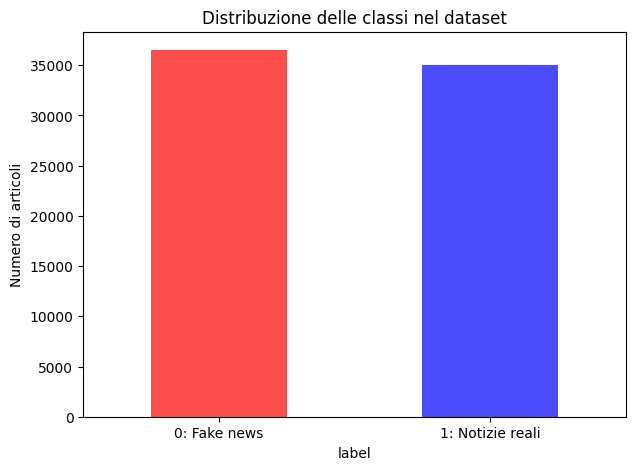

In [ ]:
dataset['label'] = dataset['label'].astype(int).map({0: 1, 1: 0})

print("\nPrime 20 righe:")
print(dataset.head(20))

print("\nClass distribution:")
print(dataset.groupby('label').size())
print("\n")

dataset['label'].value_counts().plot(kind='bar', color=['red', 'blue'], alpha=0.7, figsize=(7,5))
plt.title('Distribuzione delle classi nel dataset')
plt.xticks(ticks=[0, 1], labels=['0: Fake news', '1: Notizie reali'], rotation=0)
plt.ylabel('Numero di articoli')
plt.show()

Come si evince dal grafico a barre, il dataset risulta bilanciato, con circa 36.500 fake news e 35.000 notizie reali, perciò non sarà necessario applicare tecniche di oversampling per bilanciarle. L'accuratezza sarà una metrica affidabile per valutere le performance dei modelli.

## Istogrammi e scatter matrix

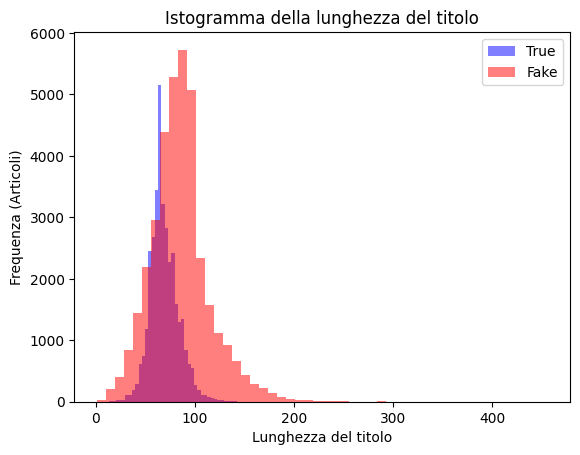

None




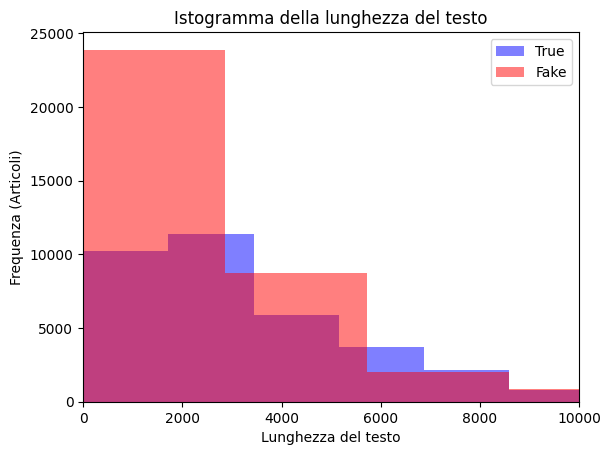

None




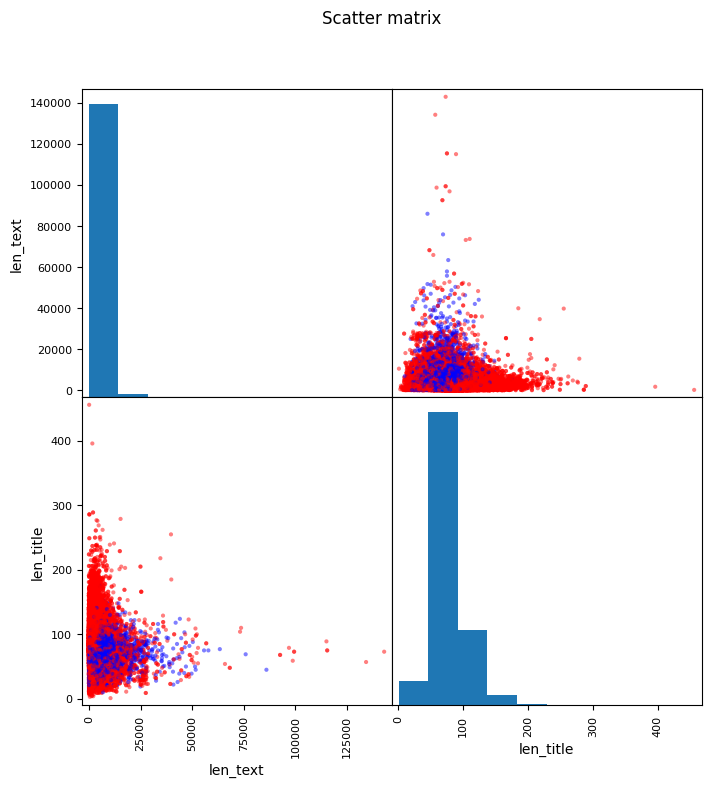

None


In [ ]:
# Creazione di feature numeriche: lunghezza del testo e del titolo
dataset['len_text'] = dataset['text'].apply(len)
dataset['len_title'] = dataset['title'].apply(len)

# Istogramma per la lunghezza del titolo
dataset[dataset['label']==1]['len_title'].plot(kind='hist', bins=50, alpha=0.5, color='blue', label='True')
dataset[dataset['label']==0]['len_title'].plot(kind='hist', bins=50, alpha=0.5, color='red', label='Fake')
plt.legend()
plt.title("Istogramma della lunghezza del titolo")
plt.xlabel("Lunghezza del titolo")
plt.ylabel("Frequenza (Articoli)")
print(plt.show())

print("\n")
# Istogramma per la lunghezza del testo
dataset[dataset['label']==1]['len_text'].plot(kind='hist', bins=50, alpha=0.5, color='blue', label='True')
dataset[dataset['label']==0]['len_text'].plot(kind='hist', bins=50, alpha=0.5, color='red', label='Fake')
plt.xlim(0, 10000) # Tagliamo i testi troppo lunghi per vedere meglio il grafico
plt.legend()
plt.title("Istogramma della lunghezza del testo")
plt.xlabel("Lunghezza del testo")
plt.ylabel("Frequenza (Articoli)")
print(plt.show())


# Scatter matrix
print("\n")
pd.plotting.scatter_matrix(dataset[['len_text', 'len_title']],
                           c=dataset['label'].map({0: 'red', 1: 'blue'}),
                           figsize=(8,8),
                           alpha=0.5)
plt.suptitle("Scatter matrix")
print(plt.show())

Dall'istogramma della lunghezza del titolo si nota che la distribuzione delle notizie vere (blu) è stretta e appuntita (ha una bassa varianza), mentre la distribuzione delle fake news (rosso) è più larga, schiacciata e spostata verso destra (ha un'alta varianza e valor medio più alto).
Una possibile interpretazione è che le notizie vere hanno standard rigidi e titolo concisi mentre le fake news usano titoli esagerati e lunghi.

Dall'istogramma della lunghezza del testo si possono notare molte fake news nel blocco a sinistra, ovvero testi molto corti, in relazione a queste le notizie vere hanno una distribuzione più omogenea di testi corti e lunghi.

Negli scatter plot della scatter matrix i dati formano una nuvola senza una chiara correlazione lineare.

Dall'analisi emerge che le due classi sono fortemente sovrapposte e non linearmente separabili utilizzando solo features di lunghezze di testo e titolo, perciò è necessario applicare tecniche per estrarre le features testuali (bag of words).

## Pre-processing e trasformazione del testo

In [ ]:
print("\nInizializzazione del trasformatore...")
# Inizializzazione del trasformatore; pulizia dei testi (trasformazione) e selezione features delle 5000 parole più importanti.
# CountVectorizer conta le parole e crea il bag of words
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_features = vectorizer.fit_transform(dataset['text'])

Y_etichette = dataset['label'].values

print("\nPre-processing completato")
print(f"Dimensione della matrice delle features (X): {X_features.shape}")

# Divisione del dataset
X_train, X_test, Y_train, Y_test = train_test_split(X_features, Y_etichette, test_size=0.2, random_state=7)
print(f"\nTesti di notizie usate per l'addestramento: {X_train.shape}")
print(f"Testi di notizie usate per il test: {X_test.shape}")


Inizializzazione del trasformatore...

Pre-processing completato
Dimensione della matrice delle features (X): (71537, 5000)

Testi di notizie usate per l'addestramento: (57229, 5000)
Testi di notizie usate per il test: (14308, 5000)


## Addestramento e Validazione dei modelli

### Naive Bayes Multinomiale

In [ ]:
# Addestramento modello con la matrice delle parole ed etichette
model_nb = MultinomialNB()
model_nb.fit(X_train, Y_train)
print("\nAddestramento Naive Bayes completato\n")

# Validazione Bayes
previsioni = model_nb.predict(X_test)
print("Confusion matrix (Naive Bayes):")
print(confusion_matrix(Y_test, previsioni))
print("\nMetriche di valutazione (Naive Bayes):")
print(classification_report(Y_test, previsioni))


Addestramento Naive Bayes completato

Confusion matrix (Naive Bayes):
[[6448  882]
 [ 972 6006]]

Metriche di valutazione (Naive Bayes):
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      7330
           1       0.87      0.86      0.87      6978

    accuracy                           0.87     14308
   macro avg       0.87      0.87      0.87     14308
weighted avg       0.87      0.87      0.87     14308



### Rete Neurale

Per la rete neurale verrà utilizzata un singolo layer nascosto da 50 neuroni, abbastanza da cogliere le relazioni non lineari tra le 5000 features testuali, senza aumentare troppo i tempi di calcolo o rischi di overfitting sul dizionario.

Il parametro *early_stopping* permette all'algoritmo di monitorare lo score di validazione e fermare l'addestramento quando smette di migliorare, prevenendo overfitting.

In [ ]:
# Livello nascosto da 50 neuroni
model_mlp = MLPClassifier(hidden_layer_sizes=(50,),
                          max_iter=20,
                          early_stopping=True,
                          random_state=7,
                          verbose=True)
print("Addestramento della rete neurale...\n")
model_mlp.fit(X_train, Y_train)
print("Addestramento completato\n")

previsioni_mlp = model_mlp.predict(X_test)
print("\nConfusion matrix (Rete Neurale):")
print(confusion_matrix(Y_test, previsioni_mlp))
print("\nMetriche di valutazione (Rete Neurale):")
print(classification_report(Y_test, previsioni_mlp))
acc_mlp = accuracy_score(Y_test, previsioni_mlp)
print(f"\nAccuracy esatta Rete Neurale: {acc_mlp:.5f}")

Addestramento della rete neurale...

Iteration 1, loss = 0.25355368
Validation score: 0.937970
Iteration 2, loss = 0.12701201
Validation score: 0.945308
Iteration 3, loss = 0.08484508
Validation score: 0.948628
Iteration 4, loss = 0.05484613
Validation score: 0.950900
Iteration 5, loss = 0.03743061
Validation score: 0.952997
Iteration 6, loss = 0.02469046
Validation score: 0.952647
Iteration 7, loss = 0.01875469
Validation score: 0.951249
Iteration 8, loss = 0.01227122
Validation score: 0.950376
Iteration 9, loss = 0.01069679
Validation score: 0.950900
Iteration 10, loss = 0.00850912
Validation score: 0.951948
Iteration 11, loss = 0.00779779
Validation score: 0.944784
Iteration 12, loss = 0.01276633
Validation score: 0.950026
Iteration 13, loss = 0.01269972
Validation score: 0.947929
Iteration 14, loss = 0.00888516
Validation score: 0.947929
Iteration 15, loss = 0.00750439
Validation score: 0.949677
Iteration 16, loss = 0.00742557
Validation score: 0.949327
Validation score did not imp

### Random Forest

In [ ]:
# Random Forest con 100 alberi decisionali
model_rf = RandomForestClassifier(n_estimators=100, random_state=7, n_jobs=-1)
print("Addestramento Random Forest...\n")
model_rf.fit(X_train, Y_train)
previsioni_rf = model_rf.predict(X_test)
print("Addestramento completato\n")

print("\nConfusion matrix (Random Forest):")
print(confusion_matrix(Y_test, previsioni_rf))
print("\nMetriche di valutazione (Random Forest):")
print(classification_report(Y_test, previsioni_rf))
acc_rf = accuracy_score(Y_test, previsioni_rf)
print(f"\nAccuracy esatta Random Forest: {acc_rf:.5f}")

Addestramento Random Forest...

Addestramento completato


Confusion matrix (Random Forest):
[[7089  241]
 [ 511 6467]]

Metriche di valutazione (Random Forest):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7330
           1       0.96      0.93      0.95      6978

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308


Accuracy esatta Random Forest: 0.94744


## Discussione e confronto dei modelli

Sulla base delle metriche di validazione estratte possiamo tratte le seguenti conclusioni:


*   Naive Bayes Multinomiale (87% Accuracy): è stato quasi istantaneo da addestrare, il risultato è buono ma essendo Naive (assumendo che le parole siano indipendenti tra loro) non è accurato quanto gli altri modelli.
*   Rete Neurale (95.5% Accuracy): con un addestramento di circa 50 secondi e 16 epoche, ha raggiunto un risultato di accuratezza quasi perfetto, molto superiore al modello Bayes.
*   Random Forest (94.7% Accuracy): ha richiesto un tempo di addestramento più lungo (circa 4 minuti), raggiungendo un risultato di accuratezza ottimo, di poco inferiore alla rete neurale.

In conclusione, la rete neurale è il modello più accurato e più efficiente per rapporto accuratezza/tempo, il random forest ci si avvicina in accuratezza ma è più lento da addestrare; il naive bayes è il più istantaneo ma il meno accurato.

### Confronto con modelli specializzati per linguaggio

I modelli testati (Naive Bayes, MLP, Random Forest) si basano sulla vettorizzazione bag of words. Sebbene le performance siano ottime, questo metodo non tiene conto delle sequenze delle parole e semantica del linguaggio.
Modelli specializzati per linguaggio come Large Language Models sarebbero in grado di considerare il contesto e la logica dei testi, permettendo una classificazione migliore.

## Risposte del test-set

In [ ]:
risposte_test = pd.DataFrame({
    'Label Reale': Y_test,
    'Risposta Bayes': previsioni,
    'Risposta MLP': previsioni_mlp,
    'Risposta RF': previsioni_rf
})

print("Prime 15 risposte del test-set a confronto:")
print(risposte_test.head(15))

Prime 15 risposte del test-set a confronto:
    Label Reale  Risposta Bayes  Risposta MLP  Risposta RF
0             1               1             1            1
1             0               0             0            0
2             0               0             0            0
3             0               0             0            0
4             0               0             0            0
5             1               1             1            1
6             1               1             1            1
7             0               0             0            0
8             0               0             0            0
9             0               0             0            0
10            1               1             1            1
11            1               0             1            1
12            0               0             0            0
13            1               1             1            1
14            0               0             0            0


Tutti e 3 i modelli hanno una buona accuratezza e ciò è visibile anche dalle prime 15 risposte del test-set. L'unico errore è del modello Bayes (il meno accurato), visibile all'indice 11.